# Visualization of Binomial Trees 

This notebook explores the binomial tree model for option pricing and compares its results with the Black-Scholes-Merton (BSM) framework for European options. 

The objective is to study pricing accuracy, convergence behavior, and the consistency of the Greeks computed under both approaches.

The notebook is organized as follows:

1. **Visualization of a Binomial Tree**
    - Construction and visualization of a binomial tree for an American put option, illustrating early exercise features.
2. **Convergence Analysis**
    - Convergence of the binomial tree price toward the BSM price for a European call option, including an error analysis as the number of time steps increases.
3. **Heatmap Error Analysis**
    - A two-dimensional error analysis showing percentage errors as functions of the stock price \($S$\) and the number of time steps \($N$\).
4. **Greeks Comparison (Delta, Gamma, Theta)**
   - A 2-step binomial tree
   - A 20-step binomial tree
   - The Black-Scholes-Merton model
5. **Greek Sensitivity (Vega and Rho)**
   - Analysis of the differences between tree-based and BSM estimates for vega and rho, including the impact of different perturbation sizes used in the finite-difference approximations.

---

## Import Packages and Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import price_option_tree, price_option_tree_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import price_option_bsm
from greeks import delta_bsm, theta_bsm, gamma_bsm, vega_bsm, rho_bsm, delta_tree, theta_tree, gamma_tree, vega_tree, rho_tree

## 1. **Visualization of a Binomial Tree**

We illustrate the structure of a binomial tree using an American put option. 
At each node, both the stock price and the corresponding option value are displayed. 
The horizontal axis represents the time to maturity.

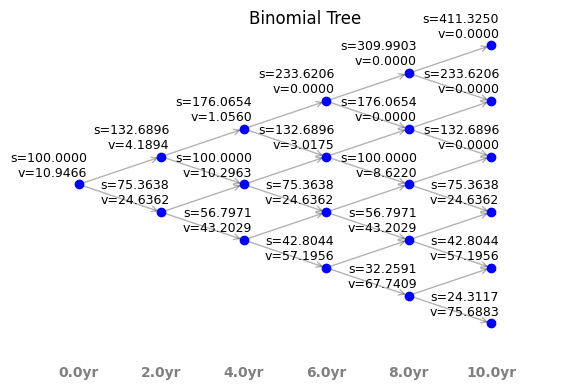

In [2]:
price, stocks, options, timeline = price_option_tree(
    option_type="put", 
    exercise_style="American", 
    s=100, 
    k=100,
    r=0.05,
    sigma=0.2, 
    T=10, 
    N=5,
    q=0,
    return_tree=True
)
   
plot_binomial_trees(stocks, options, timeline)

## 2. Convergence Analysis

- We compute the option price and Greeks (Delta, Theta, Gamma, Vega, and Rho) using both the binomial tree and the Black-Scholes-Merton (BSM)model. 
- We examine convergence and highlight the characteristic sawtooth effect as the number of time steps \($N$\) increases. 
 - In each panel, the relative error \$((\text{Tree} - \text{BSM}) / \text{BSM}$\) is displayed on the right-hand vertical axis. 

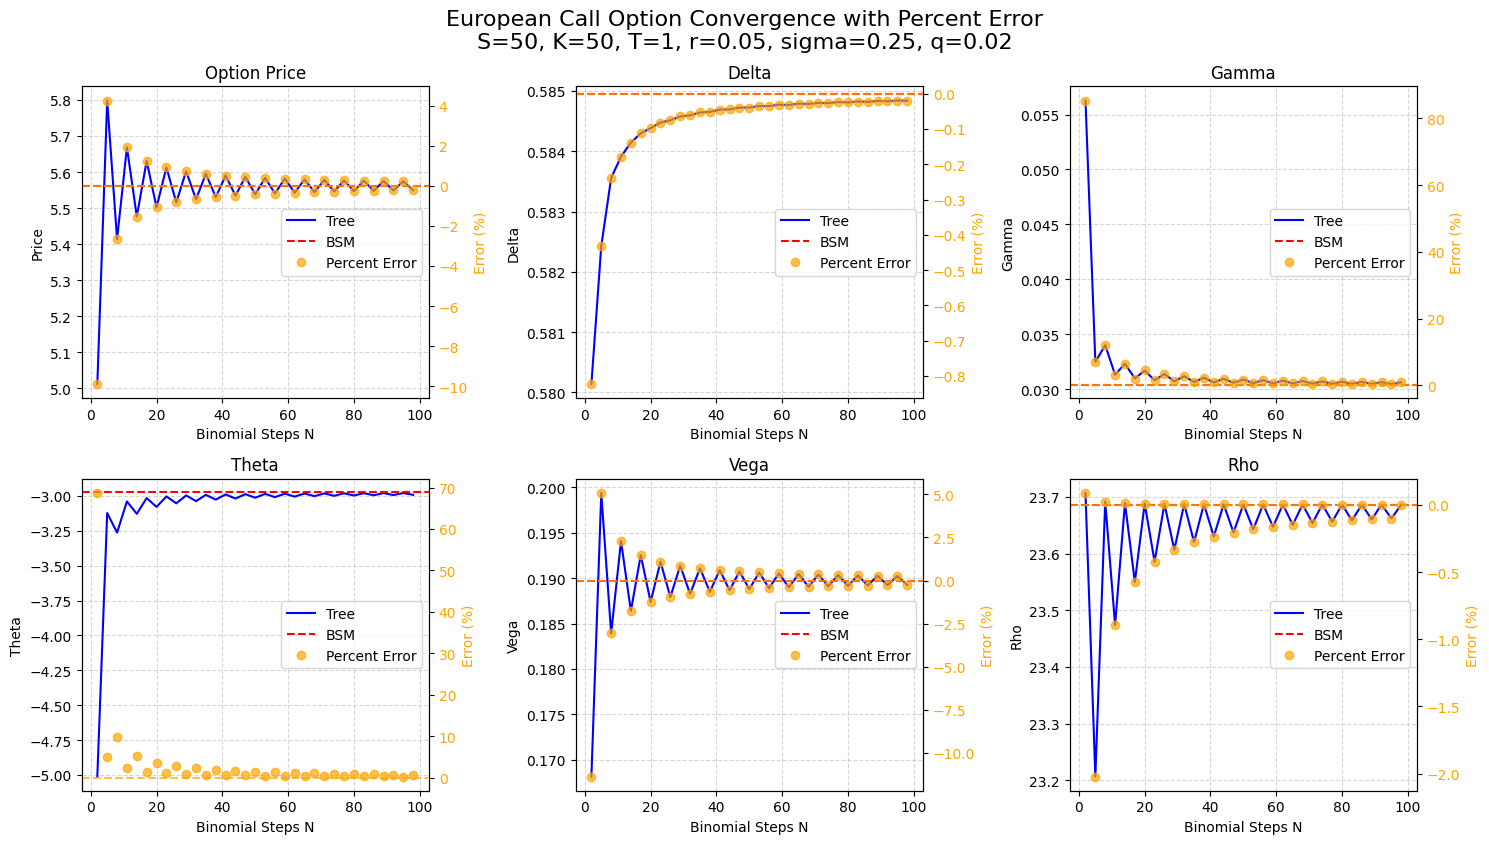

In [8]:
# Parameters
s = 50
k = 50
T = 1
r = 0.05
sigma = 0.25
q = 0.02
option_type = 'call'
exercise_style = 'European'

# Number of time steps
N_vals = np.arange(2, 100, 3)

# convergence
price_tree_vals = []
delta_tree_vals = []
gamma_tree_vals = []
theta_tree_vals = []
vega_tree_vals = []
rho_tree_vals = []

# Compute BSM values
price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)
delta_bsm_val = delta_bsm(option_type, s, k, r, sigma, T, q)
gamma_bsm_val = gamma_bsm(s, k, r, sigma, T, q)
theta_bsm_val = theta_bsm(option_type, s, k, r, sigma, T, q)
vega_bsm_val = vega_bsm(s, k, r, sigma, T, q)
rho_bsm_val = rho_bsm(option_type, s, k, r, sigma, T, q)

epsilon_vega = 1e-4
epsilon_rho = 1e-4

# Compute Tree values
for N in N_vals:
    price_tree_vals.append(price_option_tree(option_type, exercise_style, s, k, r, sigma, T, N, q, return_tree=False))
    delta_tree_vals.append(delta_tree(option_type, exercise_style, s, k, sigma, T, N, r, q))
    gamma_tree_vals.append(gamma_tree(option_type, exercise_style, s, k, sigma, T, N, r, q))
    theta_tree_vals.append(theta_tree(option_type, exercise_style, s, k, sigma, T, N, r, q))
    vega_tree_vals.append(vega_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=epsilon_vega))
    rho_tree_vals.append(rho_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=epsilon_rho))

# plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

greeks_tree = [price_tree_vals, delta_tree_vals, gamma_tree_vals,
               theta_tree_vals, vega_tree_vals, rho_tree_vals]
greeks_bsm = [price_bsm, delta_bsm_val, gamma_bsm_val,
              theta_bsm_val, vega_bsm_val, rho_bsm_val]
titles = ['Option Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']
ylabels = ['Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']

for i, ax in enumerate(axes):
    tree_vals = greeks_tree[i]
    bsm_val = greeks_bsm[i]
    
    # tree
    ax.plot(N_vals, tree_vals, label='Tree', color='blue')
    ax.axhline(bsm_val, color='red', linestyle='--', label='BSM')
    ax.set_xlabel('Binomial Steps N')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    
    # percent error (right Y-axis)
    ax2 = ax.twinx()
    percent_error = 100 * (np.array(tree_vals) - bsm_val) / bsm_val
    ax2.plot(N_vals, percent_error, 'o', color='orange', label='Percent Error', alpha=0.7)
    ax2.set_ylabel('Error (%)', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.axhline(0, color='orange', linestyle='--', alpha=0.7)

    lines_ax, labels_ax = ax.get_legend_handles_labels()
    lines_ax2, labels_ax2 = ax2.get_legend_handles_labels()
    ax.legend(lines_ax + lines_ax2, labels_ax + labels_ax2, loc='center right')

# title
plt.tight_layout()
param_title = (f"European {option_type.capitalize()} Option Convergence with Percent Error\n"
               f"S={s}, K={k}, T={T}, r={r}, sigma={sigma}, q={q}")
fig.suptitle(param_title, fontsize=16, y=1.05)
plt.show()

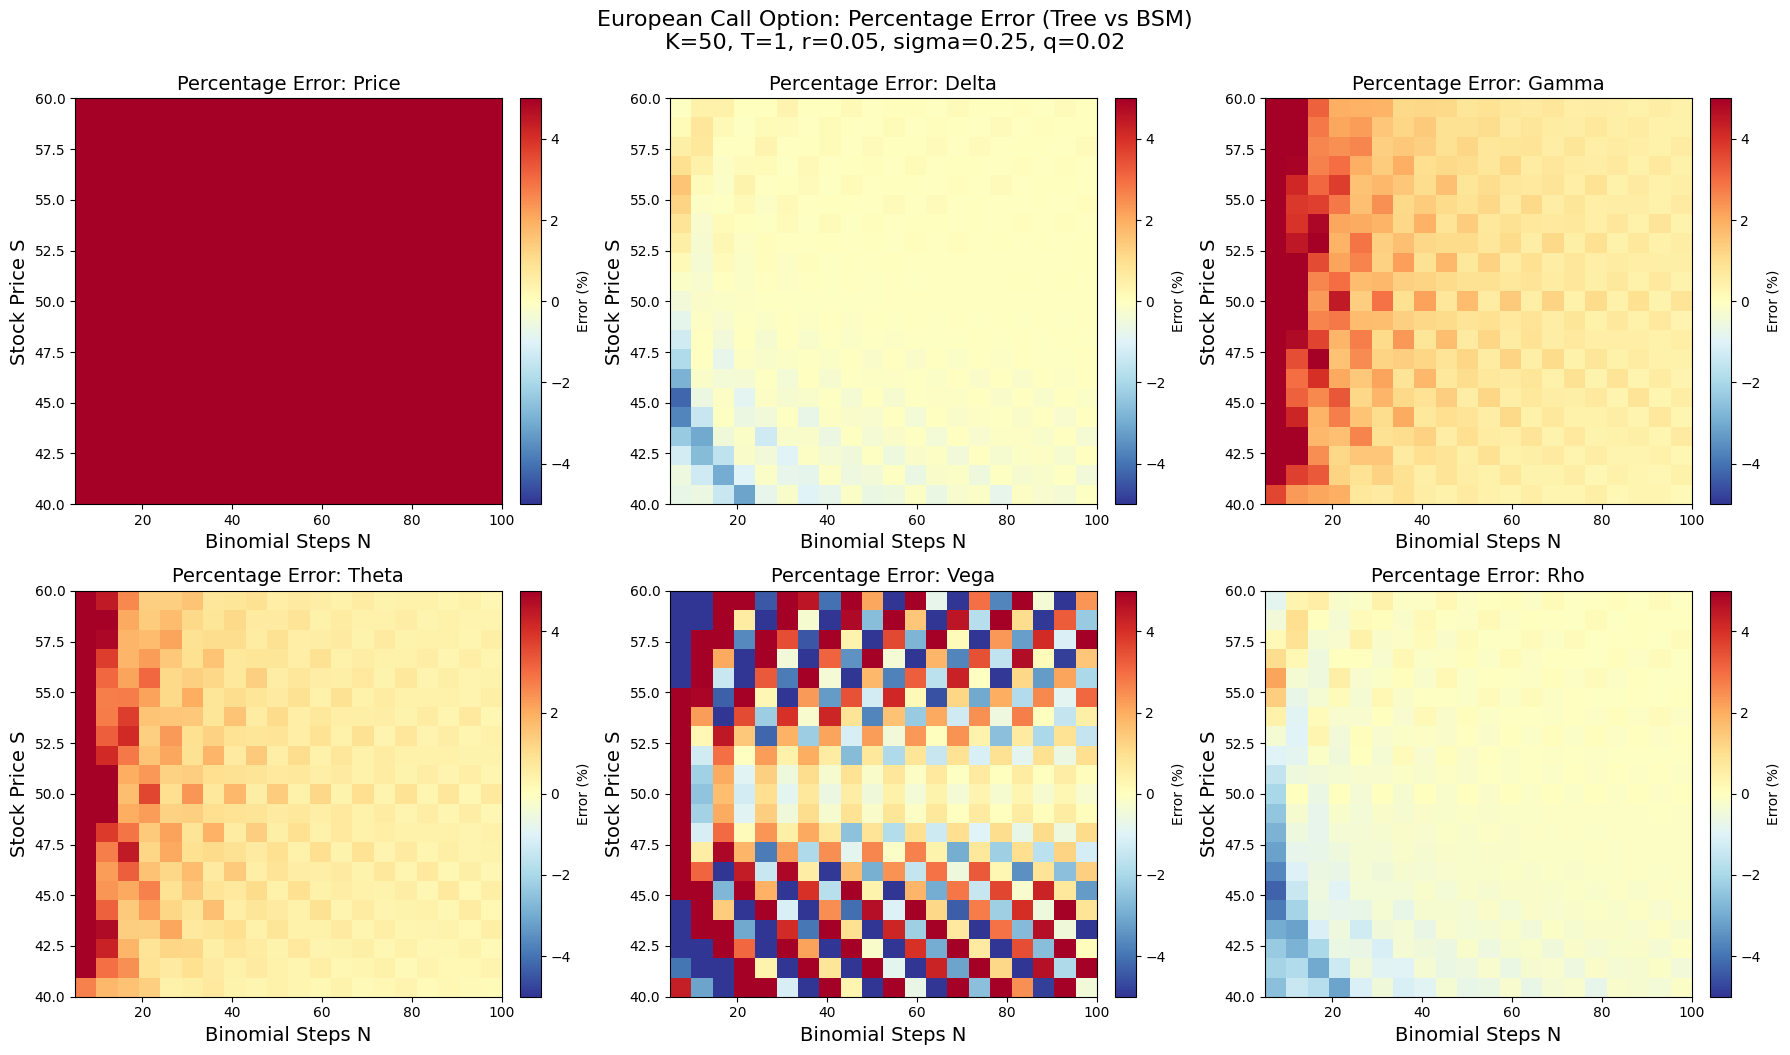

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 50
T = 1
r = 0.05
sigma = 0.25
q = 0.02
option_type = 'call'
exercise_style = 'European'

# Stock prices and binomial steps
S_vals = np.linspace(40, 60, 21)   # 21 stock prices from 40 to 60
N_vals = np.arange(5, 101, 5)      # Binomial steps from 5 to 100

epsilon_vega = 1e-4
epsilon_rho  = 1e-4

# Greeks and option price names
greeks_names = ['Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']

# Containers for percentage errors: shape (len(S_vals), len(N_vals))
errors = {name: np.zeros((len(S_vals), len(N_vals))) for name in greeks_names}

# Compute errors
for i, S in enumerate(S_vals):
    # Compute BSM values
    price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)
    delta_bsm_val = delta_bsm(option_type, S, k, r, sigma, T, q)
    gamma_bsm_val = gamma_bsm(S, k, r, sigma, T, q)
    theta_bsm_val = theta_bsm(option_type, S, k, r, sigma, T, q)
    vega_bsm_val  = vega_bsm(S, k, r, sigma, T, q)
    rho_bsm_val   = rho_bsm(option_type, S, k, r, sigma, T, q)
    
    for j, N in enumerate(N_vals):
        # Compute tree values
        price_tree = price_option_tree(option_type, exercise_style, s, k, r, sigma, T, N, q=0, return_tree=False)
        delta_tree_val = delta_tree(option_type, exercise_style, S, k, sigma, T, N, r, q)
        gamma_tree_val = gamma_tree(option_type, exercise_style, S, k, sigma, T, N, r, q)
        theta_tree_val = theta_tree(option_type, exercise_style, S, k, sigma, T, N, r, q)
        vega_tree_val  = vega_tree(option_type, exercise_style, S, k, sigma, T, N, r, q, epsilon=epsilon_vega)
        rho_tree_val   = rho_tree(option_type, exercise_style, S, k, sigma, T, N, r, q, epsilon=epsilon_rho)
        
        # Compute percentage errors
        errors['Price'][i,j] = 100 * (price_tree - price_bsm) / price_bsm
        errors['Delta'][i,j] = 100 * (delta_tree_val - delta_bsm_val) / delta_bsm_val
        errors['Gamma'][i,j] = 100 * (gamma_tree_val - gamma_bsm_val) / gamma_bsm_val
        errors['Theta'][i,j] = 100 * (theta_tree_val - theta_bsm_val) / theta_bsm_val
        errors['Vega'][i,j]  = 100 * (vega_tree_val - vega_bsm_val) / vega_bsm_val
        errors['Rho'][i,j]   = 100 * (rho_tree_val - rho_bsm_val) / rho_bsm_val

# --- Plot heatmaps in 2x3 panels ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, name in enumerate(greeks_names):
    ax = axes[idx]
    im = ax.imshow(errors[name], 
                   origin='lower', 
                   aspect='auto', 
                   extent=[N_vals[0], N_vals[-1], S_vals[0], S_vals[-1]],
                   cmap='RdYlBu_r', 
                   vmin=-5, vmax=5)  # Limit to ±5% for clarity
    ax.set_title(f'Percentage Error: {name}', fontsize=14)
    ax.set_xlabel('Binomial Steps N', fontsize=14)
    ax.set_ylabel('Stock Price S', fontsize=14)
    fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label='Error (%)')

plt.tight_layout()
param_title = (f"European {option_type.capitalize()} Option: Percentage Error (Tree vs BSM)\n"
               f"K={k}, T={T}, r={r}, sigma={sigma}, q={q}")
fig.suptitle(param_title, fontsize=16, y=1.05)
plt.show()

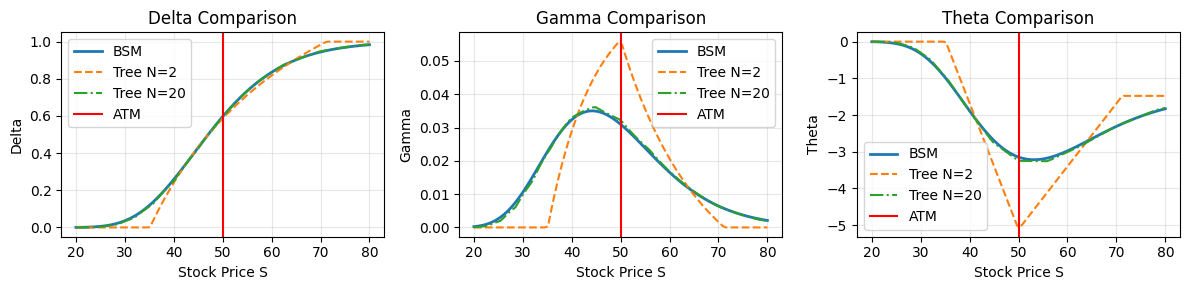

In [5]:
# Parameters
s_vals = np.linspace(20, 80, 100)
k = 50
T = 1
r = 0.03
sigma = 0.25
q = 0.0
option_type = 'call'
exercise_style = 'European'

N_small = 2
N_medium = 20

# Compute BSM Greeks
delta_bsm_vals = np.array([delta_bsm(option_type, s, k, r, sigma, T, q) for s in s_vals])
gamma_bsm_vals = np.array([gamma_bsm(s, k, r, sigma, T, q) for s in s_vals])
theta_bsm_vals = np.array([theta_bsm(option_type, s, k, r, sigma, T, q) for s in s_vals])

# Compute Tree Greeks (N=2)
delta_tree_2 = np.array([delta_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])
gamma_tree_2 = np.array([gamma_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])
theta_tree_2 = np.array([theta_tree(option_type, exercise_style, s, k, sigma, T, N_small, r, q) for s in s_vals])

# Compute Tree Greeks (N=20)
delta_tree_20 = np.array([delta_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])
gamma_tree_20 = np.array([gamma_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])
theta_tree_20 = np.array([theta_tree(option_type, exercise_style, s, k, sigma, T, N_medium, r, q) for s in s_vals])

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# delta
axes[0].plot(s_vals, delta_bsm_vals, label='BSM', linewidth=2)
axes[0].plot(s_vals, delta_tree_2, label='Tree N=2', linestyle='--')
axes[0].plot(s_vals, delta_tree_20, label='Tree N=20', linestyle='-.')
axes[0].axvline(k, color='r', linestyle='-', label='ATM')
axes[0].set_title('Delta Comparison')
axes[0].set_xlabel('Stock Price S')
axes[0].set_ylabel('Delta')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# gamma
axes[1].plot(s_vals, gamma_bsm_vals, label='BSM', linewidth=2)
axes[1].plot(s_vals, gamma_tree_2, label='Tree N=2', linestyle='--')
axes[1].plot(s_vals, gamma_tree_20, label='Tree N=20', linestyle='-.')
axes[1].axvline(k, color='r', linestyle='-', label='ATM')
axes[1].set_title('Gamma Comparison')
axes[1].set_xlabel('Stock Price S')
axes[1].set_ylabel('Gamma')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# theta
axes[2].plot(s_vals, theta_bsm_vals, label='BSM', linewidth=2)
axes[2].plot(s_vals, theta_tree_2, label='Tree N=2', linestyle='--')
axes[2].plot(s_vals, theta_tree_20, label='Tree N=20', linestyle='-.')
axes[2].axvline(k, color='r', linestyle='-', label='ATM')
axes[2].set_title('Theta Comparison')
axes[2].set_xlabel('Stock Price S')
axes[2].set_ylabel('Theta')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

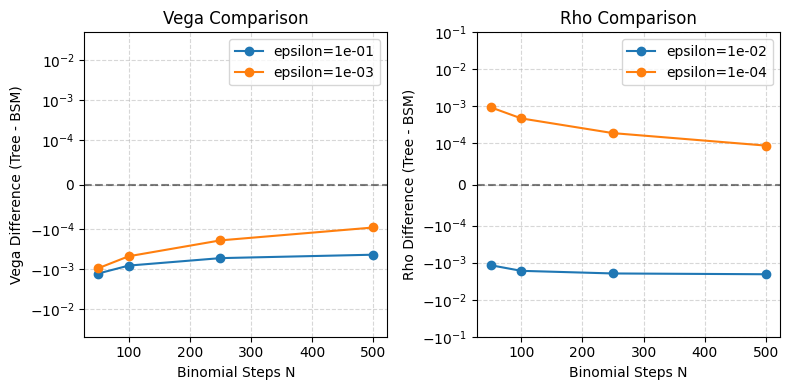

In [6]:
# Parameters
s = 50
k = 50
T = 1
r = 0.03
sigma = 0.25
q = 0.0
option_type = 'call'
exercise_style = 'European'

N_vals = np.array([50, 100, 250, 500])

# Epsilon values
epsilon_vega = [1e-1, 1e-3]
epsilon_rho = [1e-2, 1e-4]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# vega
ax = axes[0]
for eps in epsilon_vega:
    diff_list = []
    for N in N_vals:
        vega_bsm_val = vega_bsm(s, k, r, sigma, T, q)
        vega_tree_val = vega_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=eps)
        diff_list.append(vega_tree_val - vega_bsm_val)
    ax.plot(N_vals, diff_list, marker='o', label=f'epsilon={eps:.0e}')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_ylim(-5e-2, 5e-2)
ax.set_xlabel('Binomial Steps N')
ax.set_ylabel('Vega Difference (Tree - BSM)')
ax.set_title('Vega Comparison')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

# rho
ax = axes[1]
for eps in epsilon_rho:
    diff_list = []
    for N in N_vals:
        rho_bsm_val = rho_bsm(option_type, s, k, r, sigma, T, q)
        rho_tree_val = rho_tree(option_type, exercise_style, s, k, sigma, T, N, r, q, epsilon=eps)
        diff_list.append(rho_tree_val - rho_bsm_val)
    ax.plot(N_vals, diff_list, marker='o', label=f'epsilon={eps:.0e}')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yscale('symlog', linthresh=1e-4)
ax.set_ylim(-1e-1, 1e-1)
ax.set_xlabel('Binomial Steps N')
ax.set_ylabel('Rho Difference (Tree - BSM)')
ax.set_title('Rho Comparison')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()